# 🫀 Phân lớp Ung Thư Vú với Giải Thuật **AdaBoost** (Tự cài đặt từ Scratch)
### Đề tài: Khai Phá Dữ Liệu - Cuối Kỳ
### Cấu trúc dự án mới: Trực quan, gọn gàng và dễ hiểu

---
Notebook này đóng vai trò điều phối chính cho dự án. Tất cả logic xử lý phức tạp đều được tách ra thành các module chuyên biệt trong thư mục `src/`:
- `src/data_loader.py` : Tải và đọc dữ liệu
- `src/eda.py`         : Khám phá và phân tích dữ liệu trực quan
- `src/preprocessing.py` : Làm sạch, mã hóa nhãn, chuẩn hóa dữ liệu
- `src/adaboost.py`     : Giải thuật AdaBoost và DecisionStump tự phát triển
- `src/evaluation.py`   : Đánh giá hiệu quả mô hình với các metrics
- `src/visualization.py`: Trực quan hóa kết quả chi tiết (PCA, ROC, Overfitting, v.v.)

## 🛠️ Bước 1: Import thư viện & các module từ `src`

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc dự án để import module từ src ổn định hơn
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import các module nghiệp vụ
from src.data_loader import load_data
from src.eda import (
    show_overview, show_statistics, check_missing, 
    plot_diagnosis_distribution, plot_feature_histograms, plot_correlation_heatmap
)
from src.preprocessing import preprocess
from src.adaboost import AdaBoostScratch
from src.evaluation import evaluate_model
from src.visualization import (
    plot_confusion_matrix, plot_alphas_distribution,
    plot_pca_results, plot_roc_curve, plot_accuracy_vs_estimators
)

print("✅ Khởi tạo và import các module thành công!")

✅ Khởi tạo và import các module thành công!


## 📂 Bước 2: Tải và Đọc Dữ liệu

In [2]:
# Đường dẫn dữ liệu theo thư mục gốc dự án
DATA_PATH = PROJECT_ROOT / "data" / "data.csv"

df_raw = load_data(DATA_PATH)
df_raw.head()

📦 Kích thước bộ dữ liệu: 569 mẫu × 33 cột
📋 Danh sách cột: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean'] ... (tổng cộng 33 cột)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 📊 Bước 3: Khám phá Dữ liệu (EDA)

In [3]:
# 1. Xem thông tin tổng quan của dữ liệu
show_overview(df_raw)

THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perime

In [32]:
# 2. Thống kê mô tả các đặc trưng số
show_statistics(df_raw)

Thống kê mô tả các đặc trưng số:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,0.0
mean,3.037183e+07,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,NaN
std,1.250206e+08,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,NaN
min,8.670000e+03,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,NaN
25%,8.692180e+05,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,NaN
50%,9.060240e+05,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,NaN
75%,8.813129e+06,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,NaN
max,9.113205e+08,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,NaN


In [4]:
# 3. Kiểm tra giá trị khuyết thiếu (missing value)
check_missing(df_raw)

⚠️ Các cột có giá trị thiếu:
Unnamed: 32    569
dtype: int64


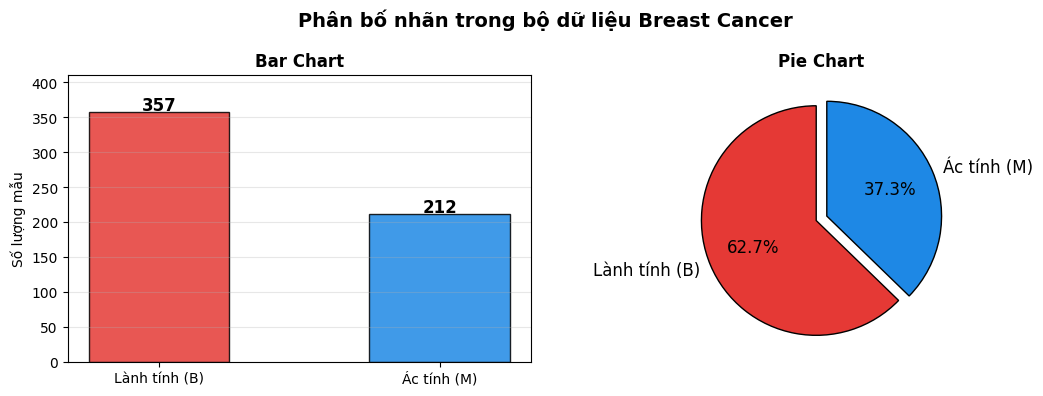


📊 Tổng số mẫu   : 569
   Ác tính (M)   : 212 mẫu (37.3%)
   Lành tính (B) : 357 mẫu (62.7%)


In [34]:
# 4. Vẽ biểu đồ phân bố nhãn diagnosis (Ác tính - M / Lành tính - B)
plot_diagnosis_distribution(df_raw)

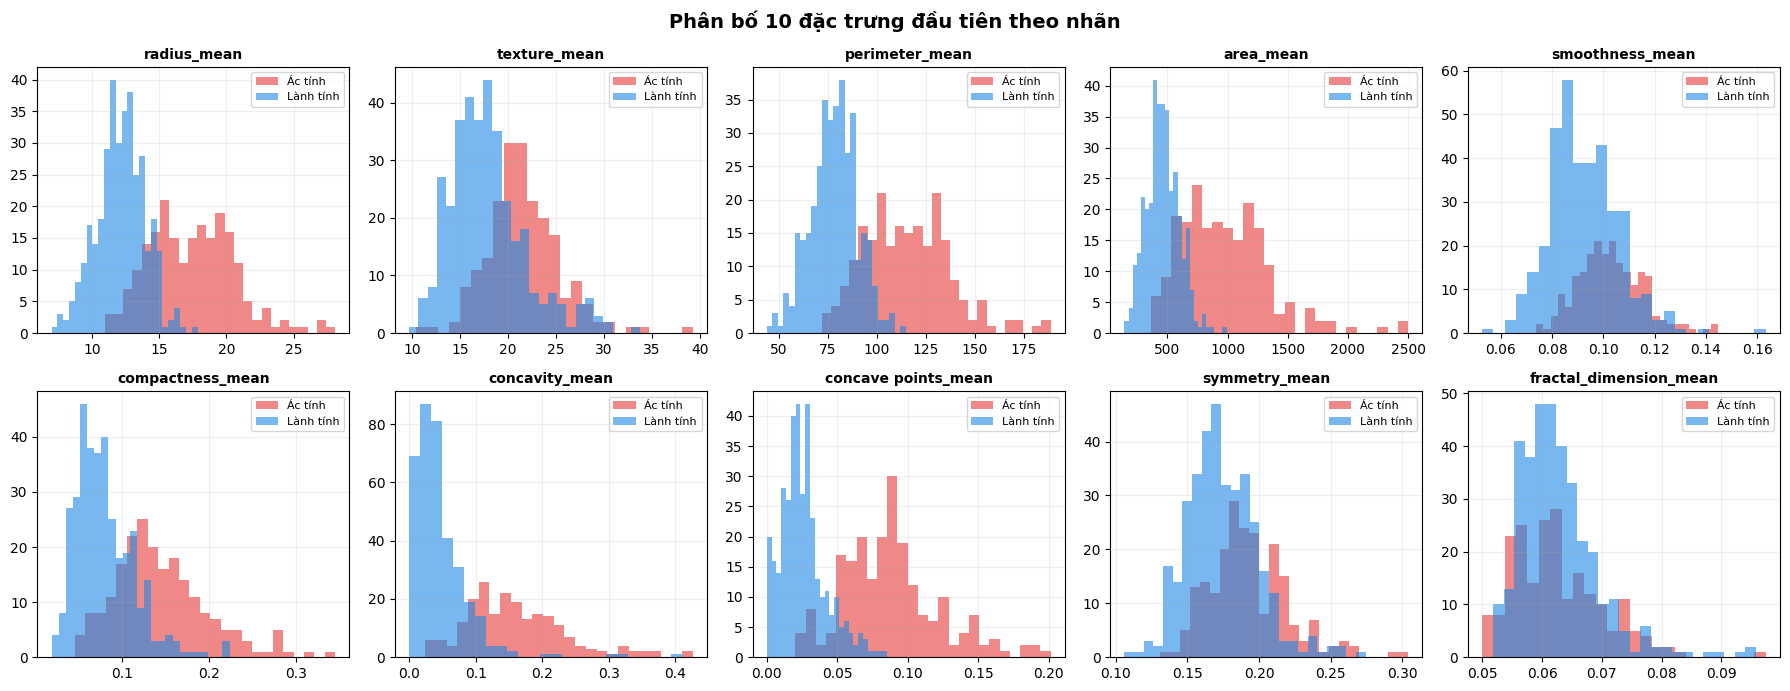

In [5]:
# 5. Xem phân phối của 10 đặc trưng đầu tiên
plot_feature_histograms(df_raw)

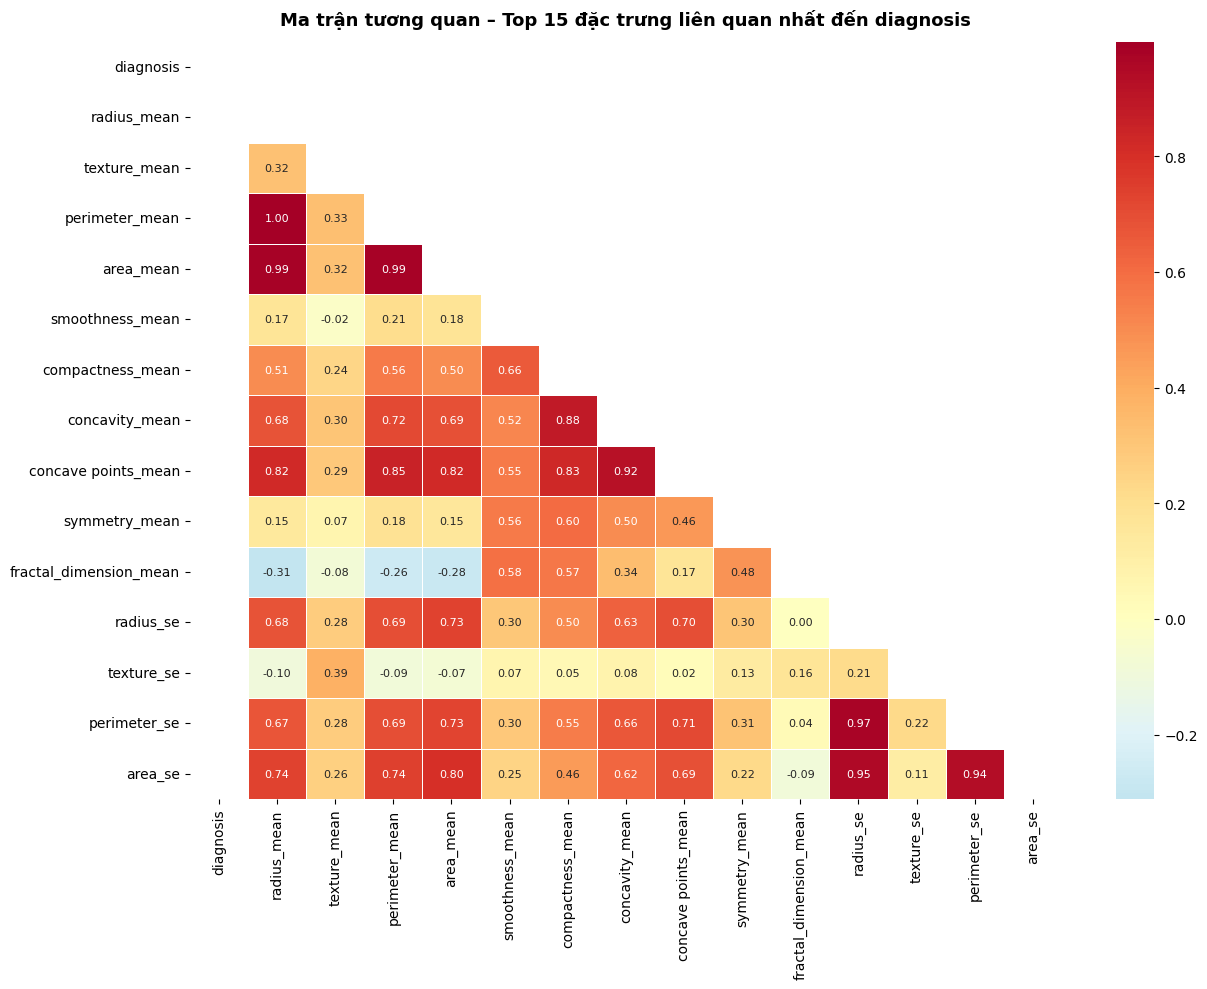

In [36]:
# 6. Ma trận tương quan của top 15 đặc trưng liên quan nhất
plot_correlation_heatmap(df_raw, top_n=15)

## ⚙️ Bước 4: Tiền xử lý Dữ liệu

In [6]:
# Thực hiện làm sạch, tách tập Train/Test và chuẩn hóa MinMaxScaler
X_train, X_test, y_train, y_test, feature_names, scaler = preprocess(df_raw, test_size=0.2, random_state=42)

✅ Đã xóa các cột không cần thiết: ['id', 'Unnamed: 32']
✅ Xóa 0 dòng có giá trị thiếu (còn 569 dòng)
✅ Mã hóa nhãn thành công: M (Ác tính) → +1 | B (Lành tính) → -1
   Phân bố nhãn sau khi mã hóa:
   - Ác tính (+1)  : 212 mẫu
   - Lành tính (-1): 357 mẫu
✅ Tách X (đặc trưng) và y (nhãn):
   - Kích thước X: (569, 30)
   - Kích thước y: (569,)
   - Số lượng đặc trưng: 30
✅ Phân chia tập huấn luyện / kiểm thử (tỷ lệ 80/20):
   - Tập Train: 455 mẫu
   - Tập Test : 114 mẫu
✅ Chuẩn hóa đặc trưng bằng MinMaxScaler về đoạn [0, 1]
   - Giá trị nhỏ nhất của Train: 0.00
   - Giá trị lớn nhất của Train: 1.00


## 🤖 Bước 5: Huấn luyện mô hình AdaBoost từ Scratch

In [7]:
N_ESTIMATORS = 50  # Bạn có thể điều chỉnh số lượng bộ phân lớp yếu ở đây

print(f'⏳ Bắt đầu huấn luyện AdaBoost từ scratch với {N_ESTIMATORS} estimators...')
model = AdaBoostScratch(n_clf=N_ESTIMATORS)
model.fit(X_train, y_train)
print('✅ Đã hoàn tất huấn luyện mô hình!')

⏳ Bắt đầu huấn luyện AdaBoost từ scratch với 50 estimators...
✅ Đã hoàn tất huấn luyện mô hình!


## 📈 Bước 6: Đánh giá mô hình

In [8]:
# Tính toán độ chính xác và các chỉ số Precision, Recall, F1
evaluation_results = evaluate_model(model, X_train, y_train, X_test, y_test)

  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADABOOST
  Số weak classifiers  : 50
  Accuracy (Train)     : 100.00%
  Accuracy (Test)      : 98.25%
  Precision            : 1.0000
  Recall               : 0.9524
  F1-Score             : 0.9756

Classification Report (Tập Test):
               precision    recall  f1-score   support

Lành tính (B)       0.97      1.00      0.99        72
  Ác tính (M)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



## 🎨 Bước 7: Trực quan hóa kết quả chi tiết

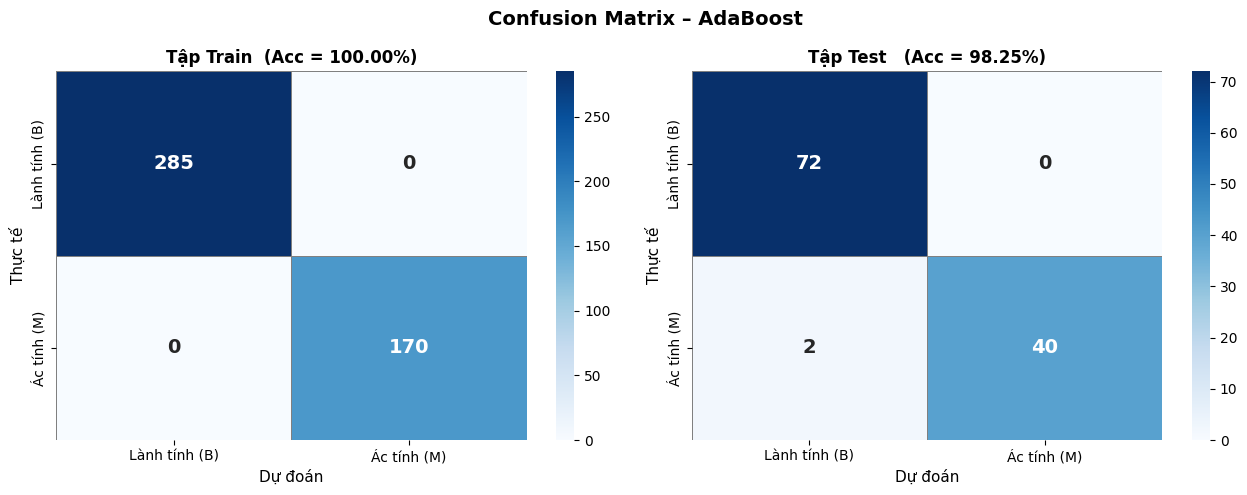

In [9]:
# 1. Vẽ Confusion Matrix
plot_confusion_matrix(
    y_train, evaluation_results['y_pred_train'], 
    y_test, evaluation_results['y_pred_test'], 
    evaluation_results['acc_train'], evaluation_results['acc_test']
)

C:\Users\Dam Hieu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Dam Hieu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


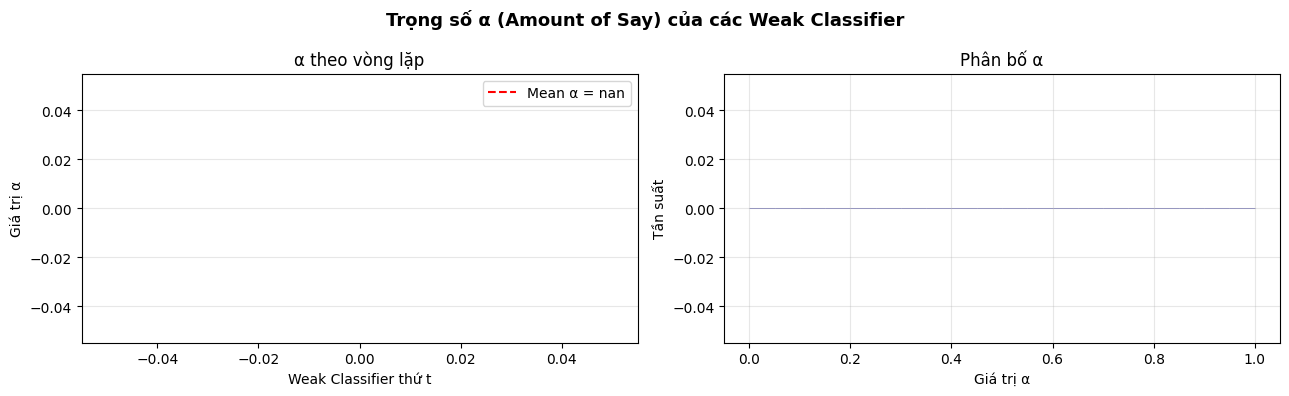

ValueError: min() iterable argument is empty

In [ ]:
# 2. Trực quan hóa phân bố trọng số alpha của các weak classifier
plot_alphas_distribution(model)

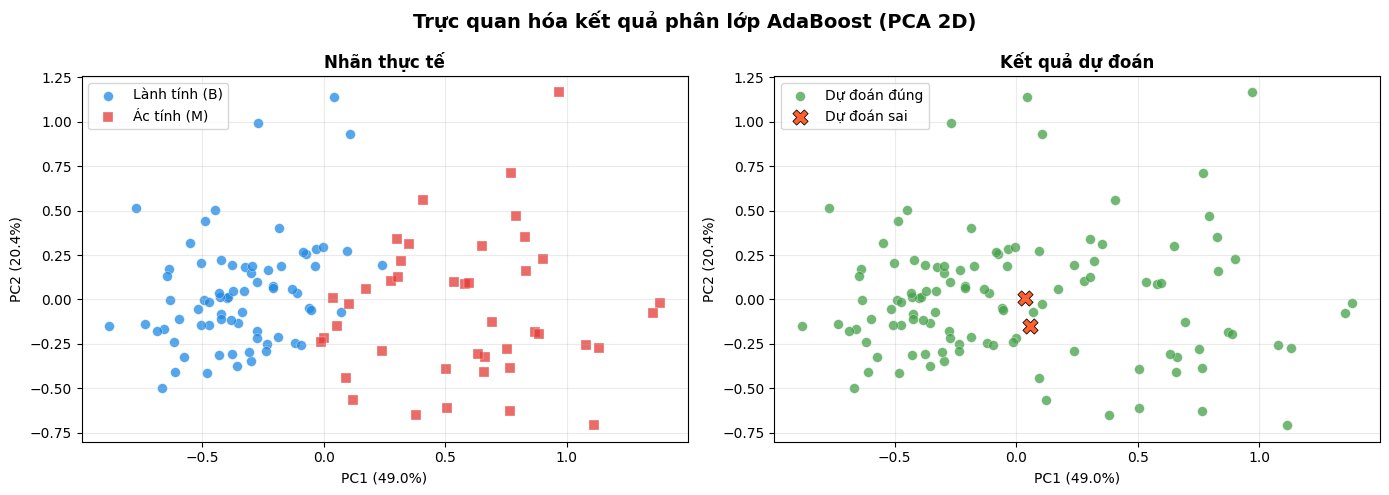

PCA giải thích 69.5% phương sai
Số mẫu dự đoán sai: 2 / 114


In [10]:
# 3. Trực quan hóa kết quả phân lớp trong không gian PCA 2D
plot_pca_results(X_test, y_test, evaluation_results['y_pred_test'])

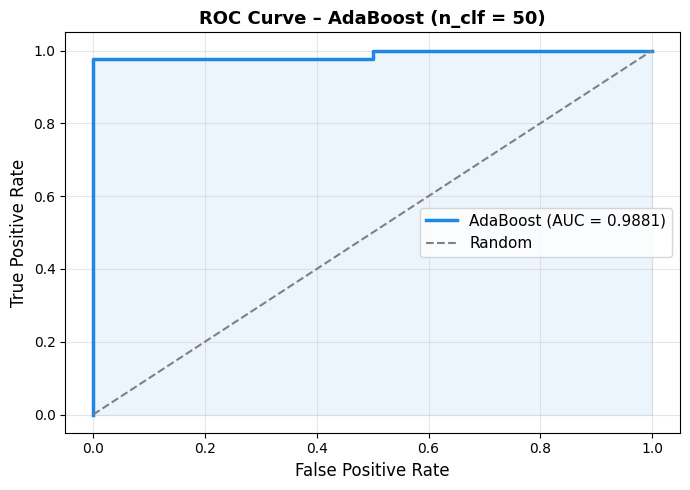

AUC = 0.9881


In [11]:
# 4. Vẽ ROC Curve và tính AUC
plot_roc_curve(model, X_test, y_test)

## 🧪 Bước 8: Thực nghiệm Accuracy theo số lượng Weak Classifiers

⏳ Đang chạy thực nghiệm thay đổi số weak classifier... (vui lòng chờ)
✅ Xong! Kết quả tốt nhất trên Test: 98.25% (n_clf = 46)


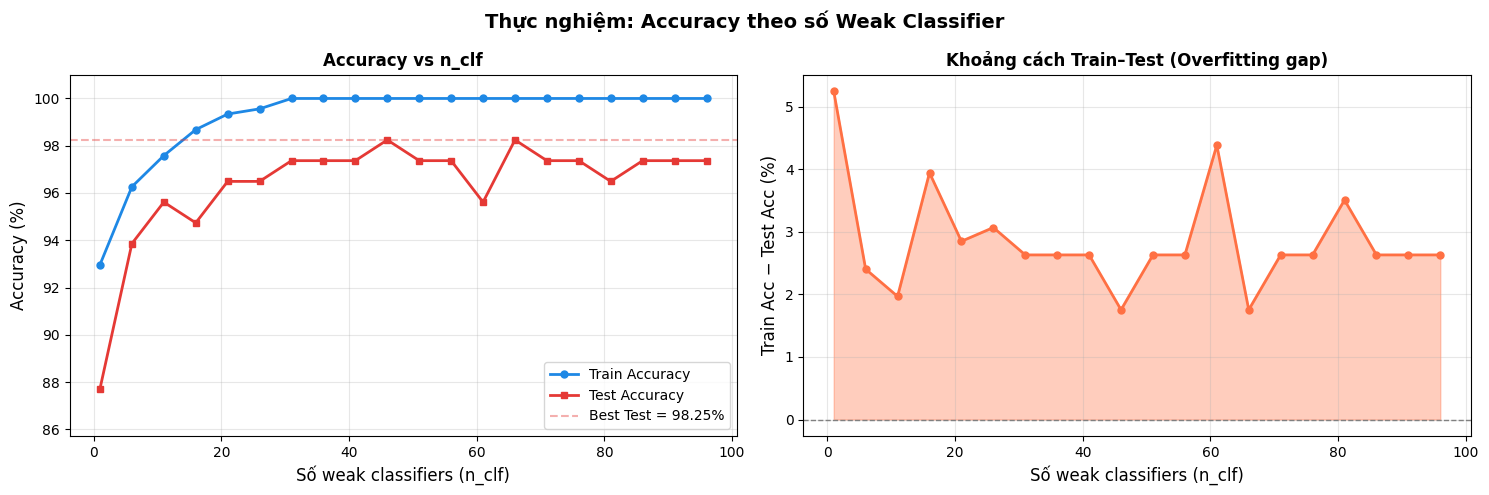

([1,
  6,
  11,
  16,
  21,
  26,
  31,
  36,
  41,
  46,
  51,
  56,
  61,
  66,
  71,
  76,
  81,
  86,
  91,
  96],
 [np.float64(92.96703296703296),
  np.float64(96.26373626373626),
  np.float64(97.58241758241758),
  np.float64(98.68131868131869),
  np.float64(99.34065934065934),
  np.float64(99.56043956043956),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0),
  np.float64(100.0)],
 [np.float64(87.71929824561403),
  np.float64(93.85964912280701),
  np.float64(95.6140350877193),
  np.float64(94.73684210526315),
  np.float64(96.49122807017544),
  np.float64(96.49122807017544),
  np.float64(97.36842105263158),
  np.float64(97.36842105263158),
  np.float64(97.36842105263158),
  np.float64(98.24561403508771),
  np.float64(97.36842105263158),
  np.float64(97.3684210526

In [12]:
# Khảo sát số lượng bộ học yếu từ 1 đến 100
clf_range = list(range(1, 101, 5))
plot_accuracy_vs_estimators(X_train, y_train, X_test, y_test, clf_range)

## 🔁 Bước 9: So sánh với các thuật toán khác

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def _get_score(model_, X_):
    if hasattr(model_, "predict_proba"):
        return model_.predict_proba(X_)[:, 1]
    if hasattr(model_, "decision_function"):
        return model_.decision_function(X_)
    return None

y_test01 = (y_test == 1).astype(int)

rows = []

# AdaBoost tu scratch (hien tai)
scratch_pred = model.predict(X_test)
scratch_score = model.predict_score(X_test)
scratch_auc = roc_auc_score(y_test01, scratch_score)
rows.append({
    "model": "AdaBoost (scratch)",
    "acc": accuracy_score(y_test, scratch_pred),
    "precision": precision_score(y_test, scratch_pred),
    "recall": recall_score(y_test, scratch_pred),
    "f1": f1_score(y_test, scratch_pred),
    "auc": scratch_auc,
})

models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "SVM-RBF": SVC(kernel="rbf", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost (sklearn)": AdaBoostClassifier(n_estimators=50, random_state=42),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    score = _get_score(m, X_test)
    auc = roc_auc_score(y_test01, score) if score is not None else None

    rows.append({
        "model": name,
        "acc": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": auc,
    })

df_compare = pd.DataFrame(rows).sort_values("acc", ascending=False)
df_compare.round(4)